## 🚀 PART-3: Perplexity-Scale Benchmarking: High-Throughput LLM Serving via AIOS
####          **Evaluating LLM Orchestration for High-Concurrency, Consumer-Grade Traffic**

- Author: Shridhar Kini (Profile)
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run: `jupyter notebook --allow-root  --port 9999 --ip=0.0.0.0`
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace ScaleTesting_PART3.ipynb`

This notebook provides a comprehensive overview of High-Concurrency Load Testing within the AIOS System framework. While standard benchmarks focus on local performance, this tutorial is designed to stress-test AIOS blocks against "Perplexity-Scale" demand—simulating the massive throughput required for modern, consumer-facing AI applications.

By leveraging the integrated AIOS Metrics System, we demonstrate how to orchestrate resources effectively, maintaining high-density token throughput (TPS) and enterprise-grade reliability even as request volume scales to hundreds of millions per month.

### Introduction: Why the Perplexity Scale?
- Not all AI deployments are created equal. To evaluate the AIOS System, we must test it against a scale that reflects modern, high-growth consumer demand. 
- We categorize these scales into five distinct tiers based on traffic volume and infrastructure requirements.
- The 5 Scales of AI Inference
    ```
    Scale Tier            Description                                          Typical RPS Range
    1. Prototype / POC    Internal testing or single-user demos.                      < 1 RPS
                          with no concurrency requirements
    2. Small Startup      Early-stage apps with a dedicated user base                1 – 10 RPS
                          (e.g., niche productivity tools).
    3. Medium Enterprise  Internal corporate tools or specialized B2B                10 – 50 RPS
                          services with hundreds of active users.
    4. Large Enterprise   Massive global brands like Amazon or Walmart using         50 – 200 RPS
                          AI for customer support/recommendations.
    5. Consumer Scale     "Crazy Scale" apps like Perplexity, ChatGPT,               350 – 5,000+ RPS
                          and Gemini used by millions globally.
    ```
#### 📊 Benchmark Reference: Perplexity AI Operational Scale (2024–2025)
This simulation uses empirical data from Perplexity AI's growth trajectory to define the target throughput requirements for high-concurrency LLM serving using the AIOS package.

🔍 Data Sources
  - NVIDIA Engineering Blog (Dec 2024): Infrastructure case study on large-scale inference. [Link](https://developer.nvidia.com/blog/spotlight-perplexity-ai-serves-400-million-search-queries-a-month-using-nvidia-inference-stack/)

  - TechCrunch / Bloomberg Tech Summit (Jun 2025): CEO statement on traffic growth. [Link](https://techcrunch.com/2025/06/05/perplexity-received-780-million-queries-last-month-ceo-says/)

##### 1. 2024 Baseline Operational Scale
- `Derived from the NVIDIA infrastructure case study`.
    ```
    Metric                    Value
    Monthly Queries         ~435,000,000
    Daily Queries           ~14,500,000
    Annualized Queries      ~5,220,000,000
    Average Throughput      ~168 RPS (Requests Per Second)
    ```

##### 2. 2025 Projected Operational Scale
- `Based on May 2025 reporting: 780M queries/month with ~20% MoM growth.`.
    ```
    Metric                    Value
    Monthly Queries         ~780,000,000
    Daily Queries           ~30,000,000
    Annualized Queries      ~9,360,000,000
    Average Throughput      ~347 RPS (Requests Per Second)
    ```

##### 🪙 Token Throughput Benchmark: for 2024 & 2025
- To simulate a "Perplexity-Scale" environment, we translate raw traffic into Hardware Load (TPS). We assume a standard AI search pipeline (retrieval + reasoning + citations) averages ~1,000 tokens per query.
    ```
    Metric                          2024 Baseline (NVIDIA Case)                 2025 Target (CEO Statement)
    Monthly Queries                  ~435 Million                                   ~780 Million
    Average RPS                      ~168 Requests/sec                              ~347 Requests/sec
    Monthly Tokens                   ~435 Billion                                   ~780 Billion
    Daily Tokens                     ~14.5 Billion                                  ~26 Billion
    Avg. Throughput (TPS)            ~168k tokens/sec                               ~347k tokens/sec
    ```

- **Note: Peak value, average could be less than this**
- **Important Considerations**
    - Models difference: What we choose to do scale test may not be same as Perplexity uses
    - Token per req: What is the total tokens(input+output+context) can be differnt from what we are testing
        - Perplexity: ~800 - 1500 tokens per request
        - Our Testing: 512 tokens per request
    - HW Availability Concerns for Hyper scale testing 
    - Cost constraints
    - we choose very high throughput model, Peplexity can use bigger model 8B,70B and so on
    - Perplexity: Several model request per input request: but we are doing only one call

### 🏙️ **Scaling**
- Scaling is the process of adjusting the number of instances of a block to meet changing demand or workload requirements.
- Scaling can be done manually or automatically based on predefined policies and rules.
- Scaling of instance across the nodes of same cluster is supported in AIOS v1.
- Use AIOS v1 Block Policy concept to define the scaling policies. example
    - Resource Allocation Policy
    - Load Balancer Policy
    - Auto-scaling Policy
    - Health Check Policy

#### 🖥️ **Resource Allocation Policy** 
- [Access Code here](policies/resource_allocator)
- Defines where the block instances should be deployed within the cluster.
- Can include rules based on blocks resource requirement and nodes resource availability, etc.
- Example: 
    - Deploy instances on nodes with at least 4 CPU and 8GB RAM available.
    - Deploy instances on nodes with at least 1 GPU with 35GB RAM available.
    - Avoid nodes with less than 20% of vcpu available.
    - Deploy instances on nodes with 1 GPU with 35GB RAM available or 2GPU with 16GB RAM available in each.
- Read this Documentation for more details on Resource Allocation Policy and its parameters: [Resource Allocation Policy Documentation](docs/README_resource_allocation.ipynb)

#### ⚖️ **Load Balancer Policy** 
- [Access Code here](policies/weighted_metrics_load_balancer)
- Manages the distribution of incoming requests across the block instances.
- Can include rules for session persistence, request routing, etc.
- Example: 
    - Route all requests from a specific user to the same instance.
    - Route all requests from a specific user session to the same instance.
    - Distribute requests evenly across all instances.
    - Route requests based on the geographic location of the user.
    - Route requests based on the type of request

- Read this Documentation for more details on Load Balancer Policy and its parameters: [Load Balancer Policy Documentation](docs/README_loadbalancer.ipynb)

#### 📈 **Auto-scaling Policy** 
- [Access Code here](policies/queue_length_scaling_metrics)
- Defines the conditions under which the block instances should be scaled up or down.
- Can include rules based on resource utilization, request rates, pending tasks(i.e queue length) etc.
- Example: 
    - Scale up when average queue length > 100 for 5 minutes.
    - Scale down when average queue length < 20 for 10 minutes.
    - Dont scale down all instance at once, keep at least 1 instance running always.
- Read this Documentation for more details on Autoscaler Policy and its parameters: [Autoscaler Policy Documentation](docs/README_autoscaler.ipynb)



#### ❤️‍🩹 **Health Check Policy** 
- [Access Code here](policies/block_healthcheck_policy)
- Defines the health check mechanisms for the block instances.
- Can include rules for determining the health status of an instance.
- Can call reassignelment of instances to other nodes if the instance is marked as unhealthy.
- Example: 
    - Mark an instance as unhealthy if it fails to respond to health checks for 3 minutes.
- Paramters and Settings:
    "failure_threshold": number of failed health checks before marking instance as reassignment.
    "check_interval_sec": frequency of health checks in seconds,
    "GATEWAY_URL": Gateway URL to call reassignement from health check policy,

### 🧪 **Load Testing Strategy**
- Load testing is the process of simulating real-world usage scenarios to evaluate the performance and scalability of a block.
- We used custom scripts to generate load on the block and monitor its performance.
- The load testing strategy includes the following steps:
    - Understand the Models capabilities and limitations;
        - Evaluate the model size(Disk, RAM, CPU, GPU requirements), Tokens limits, Latency, Throughput, 
        - Example:
            - Model: Qwen/Qwen3.5-0.8B
            - data type: fp8
            - Parameters: 0.8B
            - Disk: 1.7GB
            - GPU RAM: 4.2-4.6GB (for TP=1, 4086MiB)
            - Max Tokens: 262,144(prompt token + generation token)
            - Latency:
                - One instance in 1xB200:  0.08 sec (for 256 tokens for batch of 32)
            - Token Generation Rate:
                - One instance in 1xB200:  32x(94-98)=3136 tokens/sec (for batch of 32)
    - Understand Library used for running the inference:
        - Batching capability, Model Splitting capability (Like Tensor Parallelism, Pipeline Parallelism)etc.
            - Example: 
                - Model:  Qwen/Qwen3.5-0.8B
                - Library: vLLM
                - Batching: Yes (currently in our test 32 batch size is used)
                - Model Splitting: Yes (Tensor Parallelism)
    - Define the load testing scenarios:
        - Request per Second: 300 RPS
    - Total Tokens/sec from one VM: 8x32x(94-98) = 24064-25088 tok/sec

    - Logging/Monitoring:
        - Log the request and response times, errors, and other relevant metrics to DB.
            - We will be using TimescaleDB to storing the metrics.
            - Custom scripts to visualize above metrics
        - Monitor the resource utilization and metrics of the block instances.
            - We will be using Prometheus and Grafana for monitoring and visualization.
    - Monitor the block performance during the load test
        - check for latency, error rates, queue lengths, scaling up/down, total request processed etc.


**To  GET PORT MAPPING wrt to Service**([Doc](https://docs.aigr.id/installation/installation/#deploying-registry-services))

In [ ]:
# 🔧 Configuration Setup - Run this cell first to set up shared variables
import os

# Set configuration variables that will be available across all cells
GATEWAY_URL = "MANAGEMENTMASTER:30600"
CLUSTER_ID = "gcp-cluster-2"
GLOBAL_CLUSTER_METRICS_DB = "MANAGEMENTMASTER:30202"
GLOBAL_BLOCK_METRICS_DB = "MANAGEMENTMASTER:30201"
PARSER_URL = "MANAGEMENTMASTER:30501"
GLOBAL_CLUSTER_DB = "MANAGEMENTMASTER:30101"
GLOBAL_TASK_DB_SERVICE = "MANAGEMENTMASTER:30108"
COMPONENT_REGISTRY_SERVICE = "MANAGEMENTMASTER:30112"
GLOBAL_BLOCKDB_SERVICE = "MANAGEMENTMASTER:30100"
CLUSTER_2_MASTER_NODE = "CLUSTER_2_MASTER_NODE"
#SERVER_URL = "10.10.10.10:5000"  # For other API calls

# Set environment variables for bash cells
os.environ['GATEWAY_URL'] = GATEWAY_URL
os.environ['CLUSTER_ID'] = CLUSTER_ID
os.environ['GLOBAL_CLUSTER_METRICS_DB'] = GLOBAL_CLUSTER_METRICS_DB
os.environ['GLOBAL_BLOCK_METRICS_DB'] = GLOBAL_BLOCK_METRICS_DB
os.environ['PARSER_URL'] = PARSER_URL
os.environ['GLOBAL_CLUSTER_DB'] = GLOBAL_CLUSTER_DB
os.environ['GLOBAL_TASK_DB_SERVICE'] = GLOBAL_TASK_DB_SERVICE
os.environ['COMPONENT_REGISTRY_SERVICE'] = COMPONENT_REGISTRY_SERVICE
os.environ['GLOBAL_BLOCKDB_SERVICE'] = GLOBAL_BLOCKDB_SERVICE
#os.environ['SERVER_URL'] = SERVER_URL

print("✅ Configuration variables set:")
print(f"   • GATEWAY_URL: {GATEWAY_URL}")
print(f"   • CLUSTER_ID: {CLUSTER_ID}")
print(f"   • GLOBAL_CLUSTER_METRICS_DB: {GLOBAL_CLUSTER_METRICS_DB}")
print("\n📝 These variables are now available in both Python and bash cells!")
print("   - In Python: use GATEWAY_URL, CLUSTER_ID, GLOBAL_CLUSTER_METRICS_DB PARSER_URL GLOBAL_CLUSTER_DB GLOBAL_TASK_DB_SERVICE")
print("   - In bash: use $GATEWAY_URL, $CLUSTER_ID, $GLOBAL_CLUSTER_METRICS_DB $PARSER_URL $GLOBAL_CLUSTER_DB $GLOBAL_TASK_DB_SERVICE")
os.system('echo $GATEWAY_URL')
os.system('echo $CLUSTER_ID')
os.system('echo $GLOBAL_CLUSTER_METRICS_DB')
os.system('echo $PARSER_URL')
os.system('echo $GLOBAL_CLUSTER_DB')
os.system('echo $GLOBAL_TASK_DB_SERVICE')
os.system('echo $COMPONENT_REGISTRY_SERVICE')
os.system('echo $GLOBAL_BLOCKDB_SERVICE')
os.system('echo $GLOBAL_BLOCK_METRICS_DB')

### **Resource Allocation Policy** [Code](policies/resource_allocator)

##### Register the component

In [ ]:
%%bash
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/registerComponent \
 -d @./policies/resource_allocator/registration.json \
 -H "Content-Type: application/json" | json_pp

##### Unregister Component

In [ ]:
%%bash
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/unregisterComponent \
  -H "Content-Type: application/json" \
  -d '{"uri":"model.scaletest_block_resource_allocator:1.0.0-stable"}' | json_pp

##### Upload the Zip file of the policy

In [ ]:
%%bash
bash policies/resource_allocator/upload.sh

### **Load Balancer Policy** [Code](policies/weighted_metrics_load_balancer)

##### Register the component

In [ ]:
%%bash
bash policies/weighted_metrics_load_balancer/register.sh

##### Unregister Component

In [ ]:
%%bash
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/unregisterComponent \
  -H "Content-Type: application/json" \
  -d '{"uri":"model.weightedmetricsloadbalancer:2.0-stable"}' | json_pp

##### Upload the Zip file of the policy

In [ ]:
%%bash
bash policies/weighted_metrics_load_balancer/upload.sh

### **Auto-scaling Policy** [Code](policies/queue_length_scaling_metrics)

##### Register the component

In [ ]:
%%bash
bash policies/queue_length_scaling_metrics/register.sh

##### Unregister Component

In [ ]:
%%bash
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/unregisterComponent \
  -H "Content-Type: application/json" \
  -d '{"uri":"model.queuebasedautoscaler:2.0-stable"}' | json_pp

##### Upload the Zip file of the policy

In [ ]:
%%bash
bash policies/queue_length_scaling_metrics/upload.sh

### **Health Check Policy** [Code](policies/block_healthcheck_policy)

##### Register the component

In [ ]:
%%bash
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/registerComponent \
 -d @./policies/block_healthcheck_policy/block_health_check_registration.json \
 -H "Content-Type: application/json" | json_pp

##### Unregister Component

In [ ]:
%%bash
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/unregisterComponent \
  -H "Content-Type: application/json" \
  -d '{"uri":"model.demo_block_health_checker:1.0.0-stable"}' | json_pp

##### Upload the Zip file of the policy

In [ ]:
%%bash
bash policies/block_healthcheck_policy/upload.sh

### **Create Blocks in Cluster(With Above Policies)** [Code](model_code)

#### **Build Docker Image**

In [ ]:
%%bash
cd model_code
bash build_docker_vllm.sh

#### **Push Docker Image to Registry**

In [ ]:
%%bash
docker push MANAGEMENTMASTER:31280/vllm_batching_aios:v1

#### **Register Components**

In [ ]:
%%bash 
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/registerComponent \
  -H "Content-Type: application/json" \
  -d @./blocks/qwen3_5_0.8B_vllm/component.json | json_pp

#### **Unregister Components**

In [ ]:
%%bash
curl -X POST http://$COMPONENT_REGISTRY_SERVICE/api/unregisterComponent \
  -H "Content-Type: application/json" \
  -d '{"uri":"model.qwen3-5-0-8B-vllm:1.0.0-stable"}' | json_pp

#### **Deploy 4 Qwen 3.5 0.8B Blocks**

In [ ]:
%%bash
curl -X POST http://$PARSER_URL/api/createBlock \
 -H "Content-Type: application/json" \
 -d @./blocks/qwen3_5_0.8B_vllm/allocation.json | json_pp

In [ ]:
%%bash
curl -X POST http://$PARSER_URL/api/createBlock \
 -H "Content-Type: application/json" \
 -d @./blocks/qwen3_5_0.8B_vllm_2/allocation.json | json_pp

In [ ]:
%%bash
curl -X POST http://$PARSER_URL/api/createBlock \
 -H "Content-Type: application/json" \
 -d @./blocks/qwen3_5_0.8B_vllm_3/allocation.json | json_pp

In [ ]:
%%bash
curl -X POST http://$PARSER_URL/api/createBlock \
 -H "Content-Type: application/json" \
 -d @./blocks/qwen3_5_0.8B_vllm_4/allocation.json | json_pp

#### **Get Block Details**

In [ ]:
%%bash
curl -X GET http://$GLOBAL_BLOCKDB_SERVICE/blocks/qwen3-5-0-8b-vllm-block \
    -H "Content-Type: application/json" | json_pp

In [ ]:
%%bash
curl -X GET http://$GLOBAL_BLOCKDB_SERVICE/blocks/qwen3-5-0-8b-vllm-block-2 \
    -H "Content-Type: application/json" | json_pp

In [ ]:
%%bash
curl -X GET http://$GLOBAL_BLOCKDB_SERVICE/blocks/qwen3-5-0-8b-vllm-block-3 \
    -H "Content-Type: application/json" | json_pp

In [ ]:
%%bash
curl -X GET http://$GLOBAL_BLOCKDB_SERVICE/blocks/qwen3-5-0-8b-vllm-block-4 \
    -H "Content-Type: application/json" | json_pp

#### **Create Inference Server For The Cluster**

- Inference Server acts as a proxy for passing our inference request to correct block in AIOS
- We have created totally 9 inference server:
    - To meet the high input request volume, we have create total of 9 inference servers in current testing
    - Place these inference server where not much of network traffic is present.
        - `In the TCP/IP protocol suite, every connection is identified by a unique "5-tuple" consisting of the protocol, source/destination IP addresses, and source/destination port numbers. The TCP header allocates exactly 16 bits for the port number fields, which mathematically limits the available port range to 0 to 65,535`
        - Due to Above limitations, a VM can have maximum of 65535 open http connection. So we suggest Users to run the inference server(here 9 VMs for 9 infernece server) and client code in different VMs  
- Run this commands in your cluster node(like master node)
    - `kubectl create namespace inference-server`
    - `kubectl create -f inference_server/infer_server1.yaml` and so on for all 9 infernece server or run `$bash create_inf_server.bash`

#### **Do the Inference**

In [ ]:
%%bash
curl -X POST  http://$CLUSTER_2_MASTER_NODE:31504/v1/infer \
  -H "Content-Type: application/json" \
  -d '{
  "model": "qwen3-5-0-8b-vllm-block",
  "session_id": "session-2",
  "seq_no": 16,
  "data": {
    "mode": "chat",
    "gen_params": {
      "temperature": 0.1,
      "top_p": 0.95,
      "max_tokens": 4096
    },
    "message": "Give me code for adding two integers list element wise in python",
    "system_message": "You are a helpful assistant that provides code examples."
  },
  "graph": {},
  "files": {},
  "selection_query": {},
  "timeout": 1200
}'

#### **To Get Blocks Metrics**

In [ ]:
%%bash
curl -X GET http://$GLOBAL_BLOCK_METRICS_DB/block/qwen3-5-0-8b-vllm-block | json_pp

#### **Remove Block**

In [ ]:
%%bash
curl -X POST http://$GATEWAY_URL/controller/removeBlock/gcp-cluster-2 \
    -H "Content-Type: application/json" \
    -d '{"block_id": "qwen3-5-0-8b-vllm-block"}'

In [ ]:
%%bash
curl -X POST http://$GATEWAY_URL/controller/removeBlock/gcp-cluster-2 \
    -H "Content-Type: application/json" \
    -d '{"block_id": "qwen3-5-0-8b-vllm-block-2"}'

In [ ]:
%%bash
curl -X POST http://$GATEWAY_URL/controller/removeBlock/gcp-cluster-2 \
    -H "Content-Type: application/json" \
    -d '{"block_id": "qwen3-5-0-8b-vllm-block-3"}'

In [ ]:
%%bash
curl -X POST http://$GATEWAY_URL/controller/removeBlock/gcp-cluster-2 \
    -H "Content-Type: application/json" \
    -d '{"block_id": "qwen3-5-0-8b-vllm-block-4"}'

### 📊 **Run Response Time and Failures Visualization** [Code](streamlit_visualize_response_time.py)

- `bash setup_timescaledb_env.sh`
    - To Setup all env variables required to connect to TimescaleDB
- install dependencies:
    - `pip install -r requirements_streamlit.txt`

In [ ]:
# Run this in screen, So that this UI is always available 
bash run_visualize_response_time.sh

- to get streamlit UI:
    - In browser : `http://STREAMLIT_APP_SERVER_IP:8502/` 
        - Port and IP will vary based on your setup
- Use the test_id generated from the `llm_bench_1.js` script to visualize the response time and failures. Filter the data for selected timeranges as shown below.

    ##### Average Response Time Graph (averaged over 60 seconds)
    ![Average Response Time Graph (averaged over 60 seconds)](screenshots/avg_responsetime.png)

    ##### Total Request Count vs Time
    ![Total Request Count](screenshots/requestCount_vs_time.png)

    ##### Failed Request Count vs Time
    ![Total Request Count](screenshots/failures_vs_time.png)

    ##### Percentile (Bell Curv) Graph
    ![Percentile Grap](screenshots/percentile_curv.png)

### 🧪 Simulation Results: High-Concurrency Stress Test

Hardware Infrastructure: 4× NVIDIA HGX B200 (8-GPU per Node Configuration)

To validate the AIOS scheduler, we conducted a sustained stress test targeting the Perplexity 2025 Scale. The simulation ran for over 19 hours to measure long-term stability and thermal/memory reliability.

⏱️ Experiment Overview

Total Duration: ~19 Hours, 8 Minutes (68,880 seconds)

📈 Performance Metrics
We achieved a sustained throughput that almost exactly matches the projected May 2025 Perplexity traffic (~780M queries/month).
```
Metric                                Measured Value                 Monthly Equivalent
Throughput (RPS)                       ~298.93 RPS                     ~773 Million Requests
Token Throughput                       ~119,312 TPS                    ~309 Billion Tokens
Total Requests Processed               20,590,490                        —
Total Failures                         617                               —
Failure Rate                           0.00299%                        Enterprise Grade (99.997% Success)
```


### 📉 **Create Grafana Dashboard for Blocks metrics** [Dashboard Json](Dashboard.json)

- Add new Data Source in Grafana
    - Name: `Prometheus`
    - Prometheus Server URL: `http://prometheus-server.metrics-storage.svc.cluster.local`
    - Open http://MANAGEMENTMASTER:32199/connections/datasources
       - Note down the uid of the Prometheus in the browser URL and replaces it in all the 4 JSON files present in [Grafana Dashabord Files](grafana_dashboard)
- Open the Grafana Dashboard using the URL: http://MANAGEMENTMASTER:32199/dashboards
- Create a new dashboard and import the above json file.
    - Press `New` -> `Import` -> Upload the above json file -> Press `Import` button
- Now open the dashboard to see the metrics.
    - If any time block ID changes, update the dashboard json with new block ID or edit the panels to use the new block ID.

- Attached Few Screnshots of the dashboard below:
    - ![Dashboard1](screenshots/prometheus/1.png)
    - ![Dashboard2](screenshots/prometheus/2.png)
    - ![Dashboard3](screenshots/prometheus/3.png)
    - ![Dashboard4](screenshots/prometheus/4.png)

### 👥 **Run Client Simulation Code**

- [client code1](client_codes/llm_bench_1.js) and [client code2](client_codes/llm_bench_2.js)
    - We have used `K6 Package` for its simplicity and higher inference request capability.
      - Unlike Python-based tools that struggle with Global Interpreter Lock (GIL) overhead, `k6 is built in Go`, utilizing an efficient multi-threaded architecture. This allows a single machine to simulate thousands of concurrent users and hundreds of requests per second with minimal client-side jitter, ensuring the benchmark results reflect the server's true performance.
- Use [install k6](client_codes/install_k6.bash) script to install the package
    - Configure the ulimit to handle higher number of http request so that you will not get into issue of `Too many open files` error. Check `Miscellaneous` Section below.

- To run the code, use the command: 
    - Do changes needed for IPs present in the [client1](client_codes/llm_bench_1.js) and [client2](client_codes/llm_bench_2.js) like `INFERENCE_SERVERS` and `DMA_LOG_ENDPOINT`
    ```
    In One VM
    screen -S client1
    bash run_k6_1.bash
    ctrl a+d --> to come out of screen

    In One other VM
    screen -S client2
    bash run_k6_2.bash
    ctrl a+d --> to come out of screen

    ```
- this code is responsible for generating the load on the block by simulating multiple users know as Virtual Users(VUs) by K6. And every VU create one inference request. Maximum of 40000 VUs we have configured, beyond which client code will not generate any more request.
- better to run this code in screen  as this will run for longer duration.
    - Upon each request it calls the block endpoint and logs the response time and failure time to DMA Endpoint DB.
        -   ```json{
            "block_id":  session.block_id,
            "session_id": session.session_id,
            "seq_no": seq_no,
            "type": "success",
            "response_time": 0.0,
            "raw": "{}",
            "test_id": self.test_id,
            "user_id": self.user_id,
            "starttime": time.time(),
            "endtime": time.time(),
            "starttimeObj": datetime.now(self.ist_tz),
            "endtimeObj": datetime.now(self.ist_tz)
        }```

- Screenshot 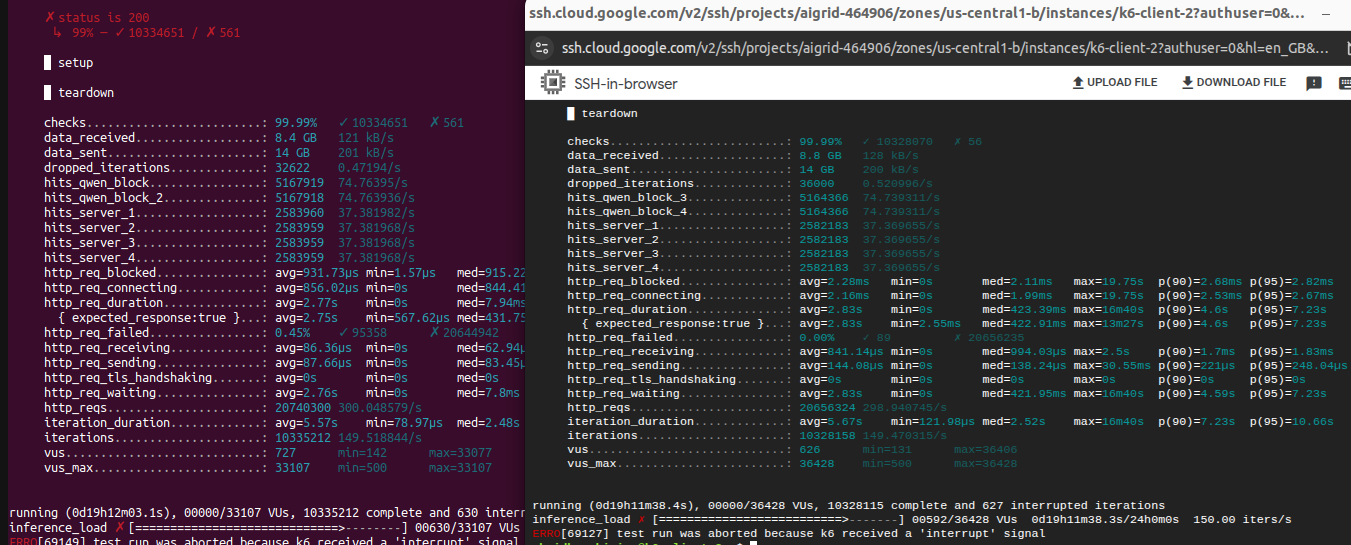

### 👥 **Run DMA User request Logging Endpoint**

- Since we are targetting very high input output request per seconds, we are going to maintina two endpoint per client to handle incoming request
- So copy [DMA TimeSacleDB Endpoint](dma_endpoint) to two different CPU Servers and Run the Apps in Screen Command i.e `$bash run.bash` and replace the IP in client js files with VM's IP

## **Miscellaneous**

#### **Procedures to Increase ulimit**
- 1. update `/etc/systemd/system.conf`
    - `$sudo nano /etc/systemd/system.conf`
    - Uncomment and set: `DefaultLimitNOFILE=65535:xxxx`
    - `$sudo systemctl daemon-reexec`

- 2. Update `/etc/security/limits.conf`
    - `$sudo nano /etc/security/limits.conf`
    - Add below 4 lines at the end of the above file and save it
        ```
        /*         soft    nofile    65535
        /*         hard    nofile    65535
        root      soft    nofile    65535
        root      hard    nofile    65535
        ```
    
- 3. update `/etc/sysctl.conf`
    - `$sudo nano /etc/sysctl.conf`
    - Change `fs.file-max = 2097152`
    - Run `$sudo sysctl -p`
 
- 4. To Check ulimits
    ``` 
    ulimit Flag 	Resource	                  systemd Directive
    -n	          Open File Descriptors	           LimitNOFILE=
    -u	          Max User Processes	           LimitNPROC=
    -s	          Stack Size	                   LimitSTACK=
    -c	          Core File Size	               LimitCORE=
    ```
    - Run like 
      - `$ulimit -n` 
      - `$ulimit -u`
    
   
- for system files
   - `$sudo systemctl edit abc.service`
        ```
        [Service]
        LimitNOFILE=65535
        LimitNPROC=65535
        ```
   - `$sudo systemctl restart abc.service`
- **IMPORTANT: 5. In Inference Server, dont forget to do this**
    - `$sudo mkdir -p /etc/systemd/system/containerd.service.d/`
    ```
        cat <<eof | sudo tee /etc/systemd/system/containerd.service.d/override.conf
        [Service]
        LimitNOFILE=1000000
        eof
    ```
    - `$sudo systemctl daemon-reload`
    - `$sudo systemctl restart containerd`